In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import holidays
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBRegressor
from prophet import Prophet

from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from fastapi import FastAPI
import uvicorn


In [170]:
df = pd.read_excel('C:/Users/ASUS/Desktop/Microgcc/Forecasting Case- Study.xlsx')

In [171]:
df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12 00:00:00,109574036.0,Beverages
1,Arizona,2019-01-12 00:00:00,109101594.6,Beverages
2,Arkansas,2019-01-12 00:00:00,58049432.2,Beverages
3,California,2019-01-12 00:00:00,444766890.6,Beverages
4,Colorado,2019-01-12 00:00:00,89816716.3,Beverages


In [172]:
df.tail()

,State,Date,Total,Category
8079,Virginia,31-10-2021,255221501.8,Beverages
8080,Washington,31-10-2021,165155956.0,Beverages
8081,West Virginia,31-10-2021,63324231.1,Beverages
8082,Wisconsin,31-10-2021,138373769.4,Beverages
8083,Wyoming,31-10-2021,19126431.9,Beverages


In [173]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   State     8084 non-null   str    
 1   Date      8084 non-null   object 
 2   Total     8084 non-null   float64
 3   Category  8084 non-null   str    
dtypes: float64(1), object(1), str(2)
memory usage: 391.4+ KB


In [174]:
df.isnull().sum()

State       0
Date        0
Total       0
Category    0
dtype: int64

In [175]:
# there are no null or missing values

In [176]:
# DATA CLEANING
# Convert date
df['Date'] = pd.to_datetime(df['Date'])


In [177]:
# Remove duplicates

df = df.drop_duplicates()


In [178]:
# Sort data

df = df.sort_values(['State', 'Date'])

In [179]:
df = df.rename(columns={'Total': 'Sales'})

In [180]:
df

,State,Date,Sales,Category
0,Alabama,2019-01-12,109574036.0,Beverages
43,Alabama,2019-03-11,112189103.8,Beverages
86,Alabama,2019-06-10,129106730.4,Beverages
129,Alabama,2019-08-12,108083723.8,Beverages
172,Alabama,2019-10-11,110932912.8,Beverages
...,...,...,...,...
3052,Wyoming,2023-07-05,23276821.3,Beverages
3095,Wyoming,2023-08-01,19531016.1,Beverages
3138,Wyoming,2023-09-04,21188735.7,Beverages
3181,Wyoming,2023-12-02,20510613.7,Beverages


In [181]:
df = df.rename(columns={'Total': 'Sales'})

In [182]:
print(df['State'].unique())

<ArrowStringArray>
[       'Alabama',        'Arizona',       'Arkansas',     'California',
       'Colorado',    'Connecticut',        'Florida',        'Georgia',
       'Illinois',        'Indiana',           'Iowa',         'Kansas',
       'Kentucky',      'Louisiana',          'Maine',       'Maryland',
  'Massachusetts',       'Michigan',      'Minnesota',    'Mississippi',
       'Missouri',       'Nebraska',         'Nevada',  'New Hampshire',
     'New Mexico',       'New York', 'North Carolina',           'Ohio',
       'Oklahoma',         'Oregon',   'Pennsylvania',   'Rhode Island',
 'South Carolina',   'South Dakota',      'Tennessee',          'Texas',
           'Utah',        'Vermont',       'Virginia',     'Washington',
  'West Virginia',      'Wisconsin',        'Wyoming']
Length: 43, dtype: str


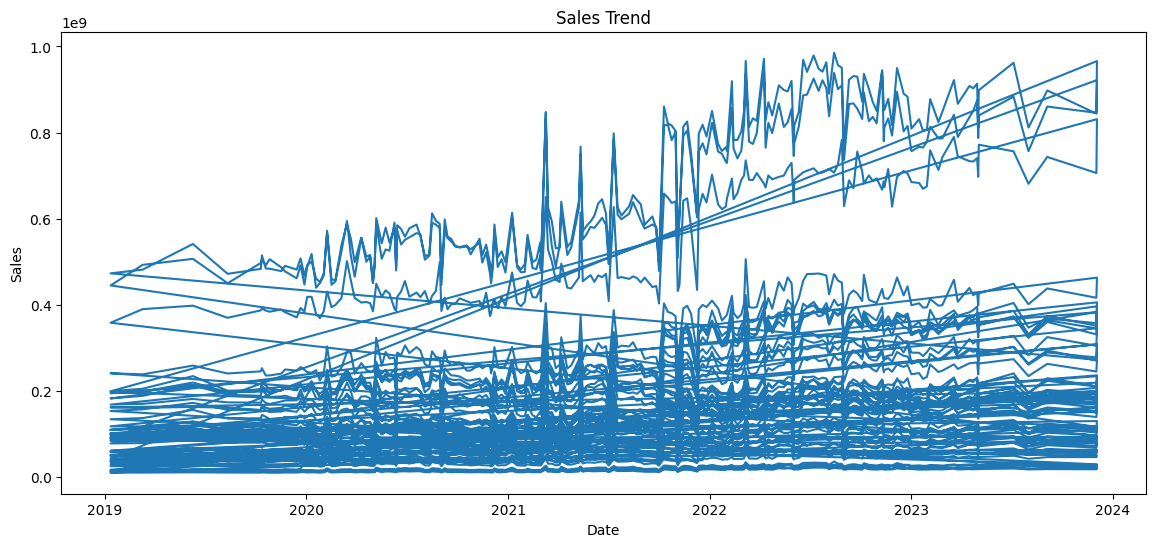

In [183]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Sales'])

plt.title('Sales Trend')

plt.xlabel('Date')

plt.ylabel('Sales')

plt.show()

In [184]:
# FEATURE ENGINEERING FUNCTION
# =========================================================


def create_features(data):

    data = data.copy()

    # Set date index
    data = data.set_index('Date')

    # Lag Features
    data['lag_1'] = data['Sales'].shift(1)
    data['lag_7'] = data['Sales'].shift(7)
    data['lag_30'] = data['Sales'].shift(30)

    # Rolling Features
    data['rolling_mean_7'] = data['Sales'].rolling(window=7).mean()
    data['rolling_std_7'] = data['Sales'].rolling(window=7).std()

    # Date Features
    data['day_of_week'] = data.index.dayofweek
    data['month'] = data.index.month
    data['week'] = data.index.isocalendar().week.astype(int)

    # Holiday Feature
    us_holidays = holidays.US()

    data['holiday'] = data.index.map(
        lambda x: 1 if x in us_holidays else 0
    )

    # Remove null rows generated from lagging
    data = data.dropna()

    return data

In [185]:
sample_state = df[df['State'] == 'California']

sample_state = create_features(sample_state)

sample_state.head()

,State,Sales,Category,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,day_of_week,month,week,holiday
Date,,,,,,,,,,,,
2020-05-07,California,585581852.4,Beverages,489779220.2,514100498.9,444766890.6,5.082009e+08,4.800132e+07,3,5,19,0
2020-05-17,California,506672447.8,Beverages,585581852.4,465090389.2,492597099.4,5.141412e+08,4.419950e+07,6,5,20,0
2020-05-24,California,528426454.4,Beverages,506672447.8,554931496.9,506587724.1,5.103547e+08,4.115303e+07,6,5,21,0
2020-05-31,California,525499508.9,Beverages,528426454.4,499937571.8,449865324.4,5.140064e+08,4.120869e+07,6,5,22,0
2020-06-09,California,590828387.0,Beverages,525499508.9,511961312.5,497063951.7,5.252732e+08,5.032858e+07,1,6,24,0


In [186]:
# EVALUATION FUNCTION


def evaluate(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(mean_squared_error(actual, predicted))

    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return mae, rmse, mape

In [187]:
# STORE RESULTS

forecast_results = {}

In [199]:
# STATE-WISE FORECASTING

states = df['State'].unique()

In [ ]:
for state in states:

    print(f'Processing State: {state}')

    state_df = df[df['State'] == state]

    # Feature Engineering
    state_df = create_features(state_df)

    # ====================================================
    # TRAIN TEST SPLIT
    # ====================================================

    train = state_df[:-56]
    test = state_df[-56:]

    # ====================================================
    # SARIMA MODEL
    # ====================================================

    sarima_model = SARIMAX(
        train['Sales'],
        order=(1,1,1),
        seasonal_order=(1,1,1,7)
    )

    sarima_fit = sarima_model.fit(disp=False)

    sarima_pred = sarima_fit.forecast(steps=56)

    _, sarima_rmse, _ = evaluate(
        test['Sales'],
        sarima_pred
    )

    # ====================================================
    # PROPHET MODEL
    # ====================================================

    prophet_train = train.reset_index()[['Date', 'Sales']]

    prophet_train.columns = ['ds', 'y']

    prophet_model = Prophet()

    prophet_model.fit(prophet_train)

    future = prophet_model.make_future_dataframe(periods=56)

    prophet_forecast = prophet_model.predict(future)

    prophet_pred = prophet_forecast['yhat'].tail(56).values

    _, prophet_rmse, _ = evaluate(
        test['Sales'],
        prophet_pred
    )

    # ====================================================
    # XGBOOST MODEL
    # ====================================================

    features = [
        'lag_1',
        'lag_7',
        'lag_30',
        'rolling_mean_7',
        'rolling_std_7',
        'day_of_week',
        'month',
        'week',
        'holiday'
    ]

    X_train = train[features]
    y_train = train['Sales']

    X_test = test[features]
    y_test = test['Sales']

    xgb_model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

    xgb_model.fit(X_train, y_train)

    xgb_pred = xgb_model.predict(X_test)

    _, xgb_rmse, _ = evaluate(
        y_test,
        xgb_pred
    )

    # ====================================================
    # LSTM MODEL
    # ====================================================

    scaler = MinMaxScaler(feature_range=(0, 1))

    scaled_data = scaler.fit_transform(
        state_df['Sales'].values.reshape(-1, 1)
    )

    sequence_length = 30

    X_lstm = []
    y_lstm = []

    for i in range(sequence_length, len(scaled_data)):

        X_lstm.append(
            scaled_data[i-sequence_length:i, 0]
        )

        y_lstm.append(
            scaled_data[i, 0]
        )

    X_lstm = np.array(X_lstm)
    y_lstm = np.array(y_lstm)

    X_lstm = X_lstm.reshape(
        X_lstm.shape[0],
        X_lstm.shape[1],
        1
    )

    split_index = len(X_lstm) - 56

    X_train_lstm = X_lstm[:split_index]
    X_test_lstm = X_lstm[split_index:]

    y_train_lstm = y_lstm[:split_index]
    y_test_lstm = y_lstm[split_index:]

    lstm_model = Sequential()

    lstm_model.add(
        LSTM(
            64,
            activation='relu',
            input_shape=(X_train_lstm.shape[1], 1)
        )
    )

    lstm_model.add(Dense(1))

    lstm_model.compile(
        optimizer='adam',
        loss='mse'
    )

    lstm_model.fit(
        X_train_lstm,
        y_train_lstm,
        epochs=20,
        batch_size=16,
        verbose=0
    )

    lstm_pred = lstm_model.predict(X_test_lstm)

    lstm_pred = scaler.inverse_transform(lstm_pred)

    y_test_actual = scaler.inverse_transform(
        y_test_lstm.reshape(-1, 1)
    )

    _, lstm_rmse, _ = evaluate(
        y_test_actual,
        lstm_pred
    )

    # ====================================================
    # MODEL COMPARISON
    # ====================================================

    results = {
        'SARIMA': sarima_rmse,
        'Prophet': prophet_rmse,
        'XGBoost': xgb_rmse,
        'LSTM': lstm_rmse
    }

    best_model_name = min(
        results,
        key=results.get
    )

    print(f'Best Model for {state}: {best_model_name}')

    # ====================================================
    # SAVE RESULTS
    # ====================================================

    forecast_results[state] = {

        'best_model': best_model_name,

        'rmse': results[best_model_name]
    }

In [197]:
import os

# SAVE RESULTS
joblib.dump(
    forecast_results,
    'forecast_results.pkl'
)

print('Training Complete')

Training Complete


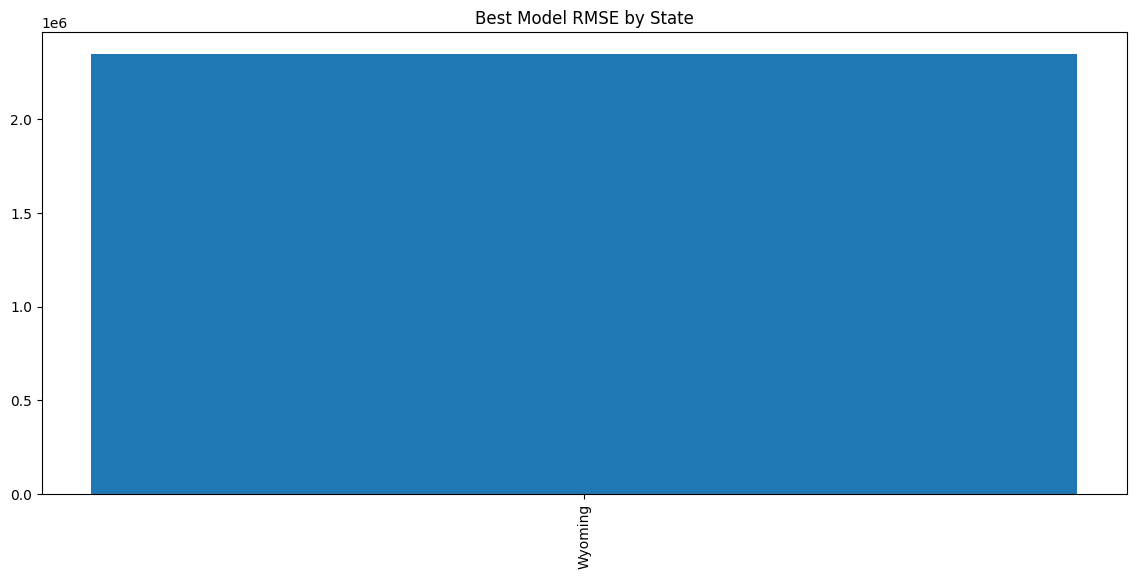

In [198]:
#RMSE Visualization
states = list(forecast_results.keys())

rmse_values = [
    forecast_results[s]['rmse']
    for s in states
]

plt.figure(figsize=(14,6))

plt.bar(states, rmse_values)

plt.xticks(rotation=90)

plt.title('Best Model RMSE by State')

plt.show()